In [1]:
import numpy as np
import faiss
import knowhere
import json


def read_bin(file_path, dtype):
    data = np.fromfile(file_path).view('int32')
    n, d = data[:2]
    return data[2:].view(dtype).reshape(n, d)


def read_vecs(file_path, dtype):
    data = np.fromfile(file_path).view('int32')
    d = data[0]
    return data.reshape(-1, d+1)[:, 1:].view(dtype)


def read_data(file_path, dtype, format):
    if format == 'bin':
        return read_bin(file_path, dtype)
    elif format == 'vecs':
        return read_vecs(file_path, dtype)

In [2]:
datasetname = 'sift'
dir = '../dataset'
format = "vecs"
metric = "L2"
normalize = False
topk = 100

xb = read_data(f'{dir}/{datasetname}/{datasetname}_base.f{format}',
               'float32', format)
xq = read_data(
    f'{dir}/{datasetname}/{datasetname}_query.f{format}', 'float32', format)
gt = read_data(
    f'{dir}/{datasetname}/{datasetname}_groundtruth.i{format}', 'int32', format)[:, :topk]
if normalize:
    xb = xb / np.linalg.norm(xb, axis=1, keepdims=True)
    xq = xq / np.linalg.norm(xq, axis=1, keepdims=True)
n, d = xb.shape
nq = xq.shape[0]
print(f'n = {n}, d = {d}, nq = {nq}')

n = 1000000, d = 128, nq = 10000


In [3]:

version = knowhere.GetCurrentVersion()

# quant = "SQ4"
# quant_types = ["SQ4", "RBQ1", "RBQ2", "RBQ3", "RBQ4"]
# colors = ["red", "blue", "green", "yellow", "purple"]
# nbits = [4, 1, 2, 3, 4]
# dims = [768, 704, 640, 576, 512, 448, 384, 320, 256]
quant_types = ["SQ4", "RBQ4"]
nbits = [4, 4]
colors = ["red", "blue"]
dims = [128, 112, 96, 80, 64]

cfg = {
    "dim": d,
    "metric_type": metric,
    "k": topk,
    "index_algo": "QUANTBF",
    "refine_ratio": 1.0
}

In [4]:
import faiss

def pca_transform(xb, xq, dim):
    d = xb.shape[1]
    pca = faiss.PCAMatrix(d, dim)
    pca.train(xb)
    xb = pca.apply_py(xb)
    xq = pca.apply_py(xq)
    return xb, xq
  
def rr_transform(xb, xq):
    d = xb.shape[1]
    rr = faiss.RandomRotationMatrix(d, d)
    rr.train(xb)
    xb = rr.apply_py(xb)
    xq = rr.apply_py(xq)
    return xb, xq
  
def pca_rr_transform(xb, xq, dim):
    xb, xq = pca_transform(xb, xq, dim)
    xb, xq = rr_transform(xb, xq)
    return xb, xq


In [5]:

mp = {}

for dim in dims:
    xb_use, xq_use = pca_rr_transform(xb, xq, dim)
    for nbit, quant, color in zip(nbits, quant_types, colors):
        bpw = dim / xb.shape[1] * nbit
        name = f"PCA{dim},{quant}"

        cfg["dim"] = dim
        cfg["build_quant_type"] = quant
        cfg["search_quant_type"] = quant
        idx = knowhere.CreateIndex("HNSW", version)
        idx.Build(knowhere.ArrayToDataSet(xb_use), json.dumps(cfg))

        ans, _ = idx.Search(knowhere.ArrayToDataSet(xq_use), json.dumps(cfg),
                            knowhere.GetNullBitSetView())

        k_dis, k_ids = knowhere.DataSetToArray(ans)

        cnt = 0
        for i in range(nq):
            cnt += np.intersect1d(k_ids[i], gt[i]).size
        recall = cnt / (nq * topk)
        print(name, recall)
        mp[name] = [bpw, recall, color]


I20250313 01:57:38.326606 32452 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250313 01:57:38.326875 32452 cardinal.cc:91] [KNOWHERE][Build][python] Index.Build with cardinal
I20250313 01:57:38.326951 32452 cardinal.cc:121] [KNOWHERE][Build][python] Plan to create Cardinal Index with BF16
I20250313 01:57:38.365725 32452 cardinal.cc:132] [KNOWHERE][Build][python] Load data with type BF16
I20250313 01:57:38.365818 32452 IVFVecIndex.cpp:88] [CARDINAL][build][python] build FLAT index
I20250313 01:57:38.400380 32452 thread_pool.h:178] [KNOWHERE][InitGlobalBuildThreadPool][python] Init global build thread pool with size 16
I20250313 01:57:38.400698 32667 thread_pool.h:68] [KNOWHERE][operator()][knowhere_build0] Successfully set priority of knowhere thread.
I20250313 01:57:38.400940 32668 thread_pool.h:68] [KNOWHERE][operator()][knowhere_build1] Successfully set priority of knowhere thread.
I20250313 01:57:38.401227 32669 thr

PCA128,SQ4 0.845545


I20250313 01:57:42.111897 32452 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250313 01:57:42.112664 32452 cardinal.cc:91] [KNOWHERE][Build][python] Index.Build with cardinal
I20250313 01:57:42.112722 32452 cardinal.cc:121] [KNOWHERE][Build][python] Plan to create Cardinal Index with BF16
I20250313 01:57:42.152616 32452 cardinal.cc:132] [KNOWHERE][Build][python] Load data with type BF16
I20250313 01:57:42.152696 32452 IVFVecIndex.cpp:88] [CARDINAL][build][python] build FLAT index
I20250313 01:57:42.254395 32452 rbq_quant.hpp:132] [CARDINAL][train][python] Training RBQ4 for 1000000 rows.
I20250313 01:57:42.260742 32452 rbq_quant.hpp:226] [CARDINAL][train][python] Done RBQ4 training
I20250313 01:57:42.260809 32452 rbq_quant.hpp:233] [CARDINAL][add][python] adding 1000000 points to RBQ4
I20250313 01:57:42.324198 32452 rbq_quant.hpp:310] [CARDINAL][add][python] perform RBQ4 compression
I20250313 01:57:44.297724 32452 rbq_q

PCA128,RBQ4 0.89084


I20250313 01:57:52.688619 32452 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250313 01:57:52.689252 32452 cardinal.cc:91] [KNOWHERE][Build][python] Index.Build with cardinal
I20250313 01:57:52.689318 32452 cardinal.cc:121] [KNOWHERE][Build][python] Plan to create Cardinal Index with BF16
I20250313 01:57:52.723769 32452 cardinal.cc:132] [KNOWHERE][Build][python] Load data with type BF16
I20250313 01:57:52.723847 32452 IVFVecIndex.cpp:88] [CARDINAL][build][python] build FLAT index
I20250313 01:57:52.788606 32452 calibrator.hpp:39] [CARDINAL][calibrate][python] AffineCalibrator calibration done, min = -85.0025, max = 84.4981, dif = 169.501
I20250313 01:57:52.827114 32452 IVFVecIndex.cpp:68] [CARDINAL][operator()][python] create ivf searcher done
I20250313 01:57:52.827538 32452 cardinal.cc:140] [KNOWHERE][Build][python] Index.Build with cardinal done
I20250313 01:57:52.827616 32452 time_recorder.cc:49] [KNOWHERE][PrintTim

...

PCA80,RBQ4 0.829609


I20250313 01:58:34.283363 32452 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250313 01:58:34.283975 32452 cardinal.cc:91] [KNOWHERE][Build][python] Index.Build with cardinal
I20250313 01:58:34.284044 32452 cardinal.cc:121] [KNOWHERE][Build][python] Plan to create Cardinal Index with BF16
I20250313 01:58:34.303431 32452 cardinal.cc:132] [KNOWHERE][Build][python] Load data with type BF16
I20250313 01:58:34.303505 32452 IVFVecIndex.cpp:88] [CARDINAL][build][python] build FLAT index
I20250313 01:58:34.341485 32452 calibrator.hpp:39] [CARDINAL][calibrate][python] AffineCalibrator calibration done, min = -107.503, max = 105.999, dif = 213.502
I20250313 01:58:34.365674 32452 IVFVecIndex.cpp:68] [CARDINAL][operator()][python] create ivf searcher done
I20250313 01:58:34.365892 32452 cardinal.cc:140] [KNOWHERE][Build][python] Index.Build with cardinal done
I20250313 01:58:34.365967 32452 time_recorder.cc:49] [KNOWHERE][PrintTim

PCA64,SQ4 0.718248


I20250313 01:58:37.937729 32452 index_factory.cc:55] [KNOWHERE][Create][python] use key HNSW_fp32 to create knowhere index HNSW with version 6
I20250313 01:58:37.938203 32452 cardinal.cc:91] [KNOWHERE][Build][python] Index.Build with cardinal
I20250313 01:58:37.938262 32452 cardinal.cc:121] [KNOWHERE][Build][python] Plan to create Cardinal Index with BF16
I20250313 01:58:37.967703 32452 cardinal.cc:132] [KNOWHERE][Build][python] Load data with type BF16
I20250313 01:58:37.967783 32452 IVFVecIndex.cpp:88] [CARDINAL][build][python] build FLAT index
I20250313 01:58:38.000198 32452 rbq_quant.hpp:132] [CARDINAL][train][python] Training RBQ4 for 1000000 rows.
I20250313 01:58:38.003163 32452 rbq_quant.hpp:226] [CARDINAL][train][python] Done RBQ4 training
I20250313 01:58:38.003228 32452 rbq_quant.hpp:233] [CARDINAL][add][python] adding 1000000 points to RBQ4
I20250313 01:58:38.067134 32452 rbq_quant.hpp:310] [CARDINAL][add][python] perform RBQ4 compression
I20250313 01:58:39.813354 32452 rbq_q

PCA64,RBQ4 0.753802


[4.0, 4.0, 3.5, 3.5, 3.0, 3.0, 2.5, 2.5, 2.0, 2.0] [0.845545, 0.89084, 0.831803, 0.885275, 0.810179, 0.865873, 0.773247, 0.829609, 0.718248, 0.753802]


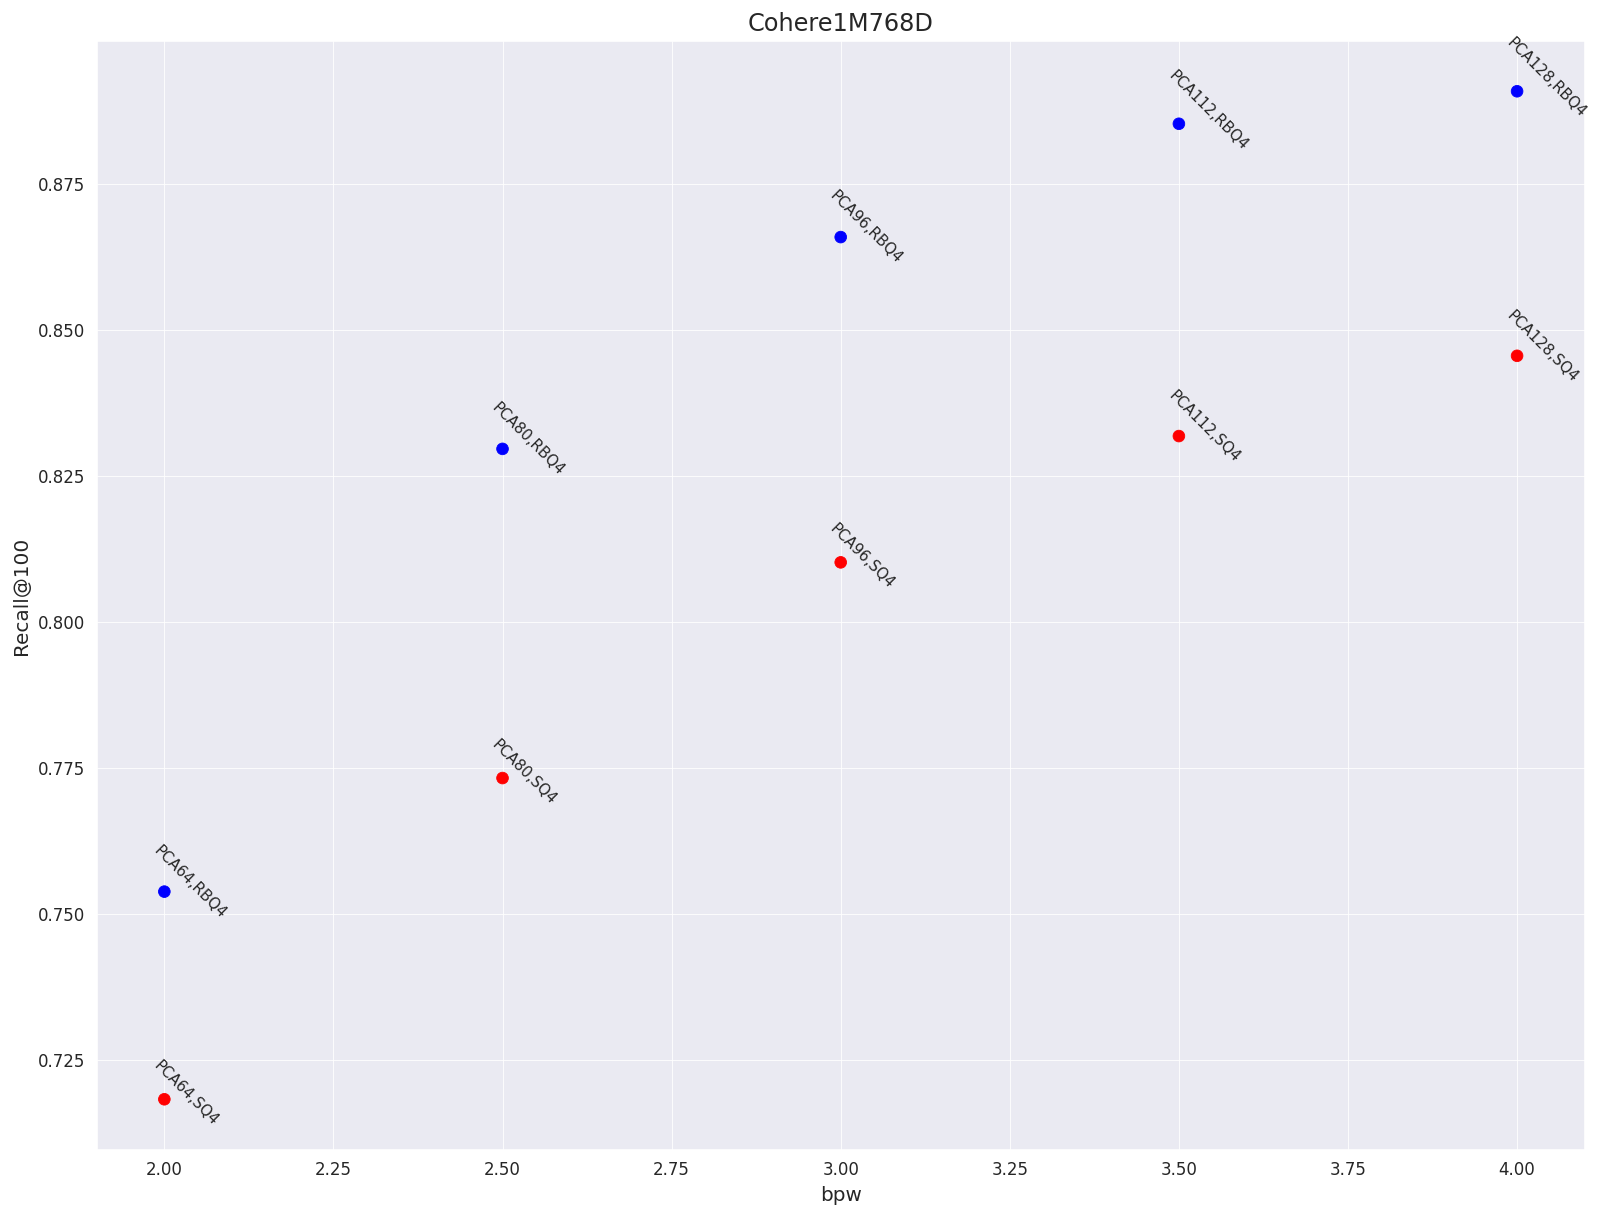

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.use('seaborn-whitegrid')
sns.set_style('whitegrid')
# plt.style.use('bmh')
plt.figure(figsize=(16, 12), dpi=120)
vals = list(mp.values())
x, y, c = [_[0] for _ in vals], [_[1] for _ in vals], [_[2] for _ in vals]
print(x, y)
plt.scatter(x, y, marker='o', c=c)
for i, (xi, yi, label, color) in enumerate(zip(x, y, list(mp.keys()), c)):
    plt.text(xi-0.02, yi-0.005, label, rotation=-45, fontsize=9, ha='left', va='bottom')
plt.xlabel('bpw')
plt.ylabel('Recall@100')
plt.title('Cohere1M768D')
plt.savefig(f'pca_bench_{datasetname}.png')